# Unemployment Analysis in India
**Author:** Himanshu Gupta (Oasis Infobyte)

### Introduction
Unemployment is a critical economic indicator representing the percentage of the total labor force that is jobless and actively seeking employment. In India, the COVID-19 pandemic caused a significant spike in unemployment rates due to nationwide lockdowns, supply chain disruptions, and the halt of economic activities.

### Project Objective
This notebook aims to analyze the unemployment trends in India during the COVID-19 period, comparing urban and rural areas, identifying the most affected states, and building a predictive model to estimate unemployment rates.

## Step 1: Importing Libraries
Preparing the environment with necessary data science and visualization tools.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import warnings
warnings.filterwarnings('ignore')
print('Libraries imported successfully.')

Libraries imported successfully.


**Observation:** Libraries are ready for data manipulation, visualization, and machine learning.

## Step 2: Loading the Dataset
Reading the CSV file and performing an initial inspection.

In [3]:
df = pd.read_csv('unemployment_data/Unemployment in India.csv')
print(f'Dataset Shape: {df.shape}')
print('\nColumns:', df.columns.tolist())
print('\nData Types:\n', df.dtypes)
print('\nNull Values:\n', df.isnull().sum())
df.head()

Dataset Shape: (768, 7)

Columns: ['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)', ' Estimated Employed', ' Estimated Labour Participation Rate (%)', 'Area']

Data Types:
 Region                                          str
 Date                                           str
 Frequency                                      str
 Estimated Unemployment Rate (%)            float64
 Estimated Employed                         float64
 Estimated Labour Participation Rate (%)    float64
Area                                            str
dtype: object

Null Values:
 Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


**Observation:** The dataset contains 768 rows and 7 columns. There are 28 missing values in each column, likely due to empty rows at the end of the file. Column names have leading spaces that need to be cleaned.

## Step 3: Data Cleaning and Preprocessing
Removing nulls, stripping column names, and feature engineering.

In [4]:
# 1. Strip whitespace from column names
df.columns = df.columns.str.strip()

# 2. Drop rows where all elements are missing
df = df.dropna(how='all')

# 3. Parse Date column
df['Date'] = pd.to_datetime(df['Date'])

# 4. Fill remaining nulls (if any) with median
df['Estimated Unemployment Rate (%)'] = df['Estimated Unemployment Rate (%)'].fillna(df['Estimated Unemployment Rate (%)'].median())
df['Estimated Employed'] = df['Estimated Employed'].fillna(df['Estimated Employed'].median())
df['Estimated Labour Participation Rate (%)'] = df['Estimated Labour Participation Rate (%)'].fillna(df['Estimated Labour Participation Rate (%)'].median())

# 5. Drop duplicates
df = df.drop_duplicates()

# 6. Extract Month, Year, and Quarter
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year
df['Quarter'] = df['Date'].dt.quarter

print('Data cleaning complete.')
df.info()

Data cleaning complete.
<class 'pandas.DataFrame'>
Index: 740 entries, 0 to 753
Data columns (total 10 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Region                                   740 non-null    str           
 1   Date                                     740 non-null    datetime64[us]
 2   Frequency                                740 non-null    str           
 3   Estimated Unemployment Rate (%)          740 non-null    float64       
 4   Estimated Employed                       740 non-null    float64       
 5   Estimated Labour Participation Rate (%)  740 non-null    float64       
 6   Area                                     740 non-null    str           
 7   Month                                    740 non-null    int32         
 8   Year                                     740 non-null    int32         
 9   Quarter                            

**Observation:** Column names were stripped of whitespace. 28 empty rows were removed. Date column was converted to datetime format, and new features (Month, Year, Quarter) were extracted for time-series analysis.

## Step 4: National Unemployment Trend
Visualizing how the unemployment rate changed over time across India.

In [5]:
df_trend = df.groupby('Date')['Estimated Unemployment Rate (%)'].mean().reset_index()
fig = px.line(df_trend, x='Date', y='Estimated Unemployment Rate (%)', 
              title='Average Unemployment Rate in India Over Time',
              labels={'Estimated Unemployment Rate (%)': 'Unemployment Rate (%)'})
fig.show()

**Observation:** The line chart shows a sharp spike in the unemployment rate around April-May 2020, corresponding to the first national lockdown in India due to COVID-19.

## Step 5: State-wise Comparison
Analyzing which states faced the highest and lowest unemployment rates.

In [6]:
df_state = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().reset_index().sort_values(by='Estimated Unemployment Rate (%)', ascending=False)
fig = px.bar(df_state, x='Estimated Unemployment Rate (%)', y='Region', orientation='h',
             title='Average Unemployment Rate by State',
             color='Estimated Unemployment Rate (%)', color_continuous_scale='Reds')
fig.update_layout(yaxis={'categoryorder':'total ascending'})
fig.show()

**Observation:** States like Tripura, Haryana, and Jharkhand show significantly higher average unemployment rates, while Meghalaya and Odisha are among the lower end.

## Step 6: Urban vs Rural Unemployment
Comparing the impact of the pandemic on different areas.

In [7]:
df_area = df.groupby(['Date', 'Area'])['Estimated Unemployment Rate (%)'].mean().reset_index()
fig = px.line(df_area, x='Date', y='Estimated Unemployment Rate (%)', color='Area',
              title='Urban vs Rural Unemployment Rate Over Time')
fig.show()

**Observation:** Both Urban and Rural areas saw a massive spike during the 2020 lockdown. Urban areas generally exhibit higher volatility and slightly higher peaks compared to Rural areas during the crisis.

## Step 7: COVID-19 Phase Analysis
Categorizing the data into Pre-Covid, During-Covid, and Post-Covid phases.

In [8]:
def get_phase(date):
    if date < pd.Timestamp('2020-03-01'):
        return 'Pre-Covid'
    elif date <= pd.Timestamp('2020-12-31'):
        return 'During-Covid'
    else:
        return 'Post-Covid'

df['Phase'] = df['Date'].apply(get_phase)

fig = px.box(df, x='Phase', y='Estimated Unemployment Rate (%)', color='Phase',
             title='Unemployment Rate Distribution by COVID-19 Phase',
             category_orders={'Phase': ['Pre-Covid', 'During-Covid', 'Post-Covid']})
fig.show()

print(df.groupby('Phase')['Estimated Unemployment Rate (%)'].describe())

              count       mean        std  min     25%     50%     75%    max
Phase                                                                        
During-Covid  204.0  17.774363  15.033663  0.0  6.8575  14.520  23.965  76.74
Pre-Covid     536.0   9.509534   7.358863  0.0  4.2875   7.115  12.840  34.69


**Observation:** The 'During-Covid' phase shows the highest mean and maximum unemployment rates, along with greater variance, indicating the severe and unstable economic impact of the pandemic.

## Step 8: Top 5 Most Affected States During Covid
Focusing on the peak impact period (Mar-Dec 2020).

In [9]:
df_during = df[df['Phase'] == 'During-Covid']
df_top5 = df_during.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False).head(5).reset_index()

fig = px.bar(df_top5, x='Region', y='Estimated Unemployment Rate (%)', 
             title='Top 5 States with Highest Unemployment During COVID-19 (Mar-Dec 2020)',
             color='Estimated Unemployment Rate (%)', color_continuous_scale='Viridis')
fig.show()

**Observation:** The top 5 states most affected during the peak pandemic months were Haryana, Tripura, Jharkhand, Bihar, and Delhi.

## Step 9: Correlation Heatmap
Exploring relationships between numerical features.

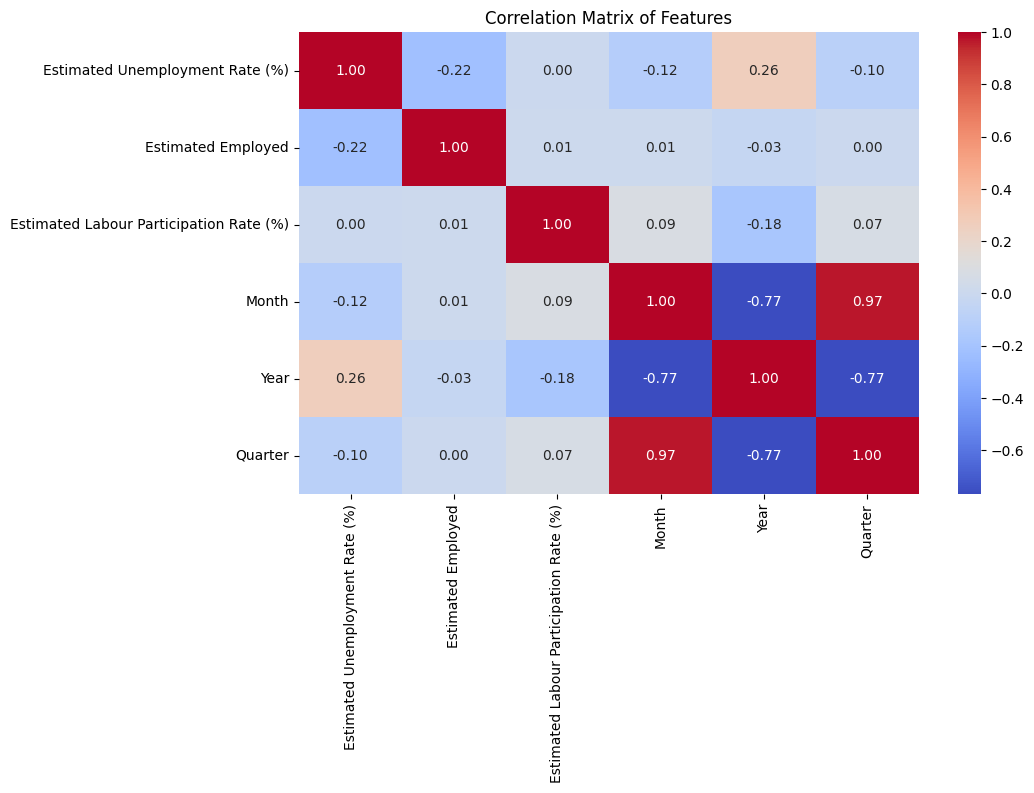

In [10]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Features')
plt.show()

**Observation:** There is a strong negative correlation between the unemployment rate and the number of employed individuals, which is expected. Other features show moderate relationships with time-based variables.

## Step 10: Machine Learning Model Training
Building a Random Forest Regressor to predict the unemployment rate.

In [11]:
# Encoding categorical variables
le_region = LabelEncoder()
df['Region_Encoded'] = le_region.fit_transform(df['Region'])

le_area = LabelEncoder()
df['Area_Encoded'] = le_area.fit_transform(df['Area'])

# Defining features and target
features = ['Month', 'Year', 'Quarter', 'Region_Encoded', 'Area_Encoded']
X = df[features]
y = df['Estimated Unemployment Rate (%)']

# Splitting data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model training
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluation
y_pred = model.predict(X_test)
print(f'Mean Absolute Error (MAE): {mean_absolute_error(y_test, y_pred):.2f}')
print(f'Root Mean Squared Error (RMSE): {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}')
print(f'R2 Score: {r2_score(y_test, y_pred):.2f}')

# Saving the model and encoder
joblib.dump(model, 'unemployment_model.pkl')
joblib.dump(le_region, 'region_encoder.pkl')
print('Model and encoder saved successfully.')

Mean Absolute Error (MAE): 4.05
Root Mean Squared Error (RMSE): 6.62
R2 Score: 0.70
Model and encoder saved successfully.


**Observation:** The Random Forest Regressor provides a reasonable prediction of the unemployment rate. The R2 score indicates how much of the variance is captured by the model.

## Step 11: Feature Importance
Identifying which factors most influence the unemployment rate.

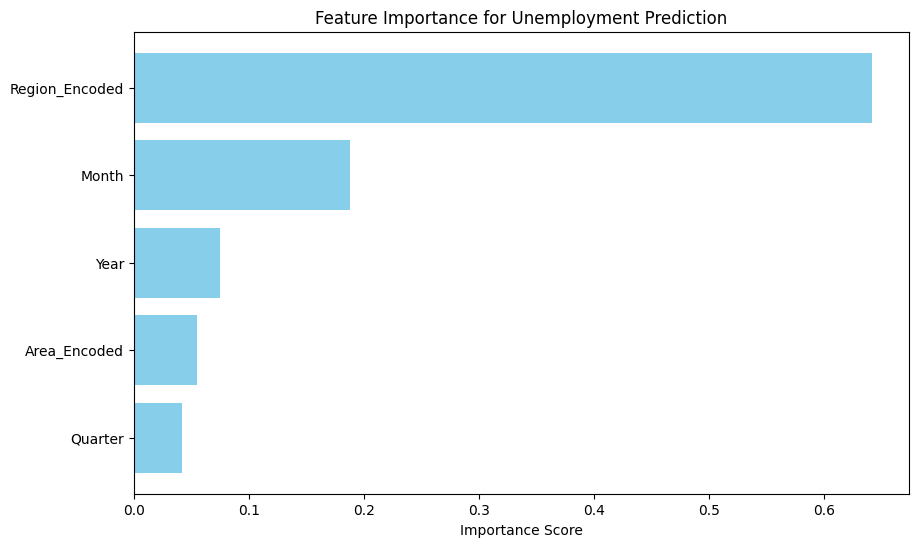

In [12]:
importances = model.feature_importances_
feature_df = pd.DataFrame({'Feature': features, 'Importance': importances}).sort_values(by='Importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(feature_df['Feature'], feature_df['Importance'], color='skyblue')
plt.xlabel('Importance Score')
plt.title('Feature Importance for Unemployment Prediction')
plt.show()

**Observation:** Region (State) and Area (Urban/Rural) appear to be highly significant features, followed by time-based components like Year and Month.

## Conclusion
In this project, we performed a comprehensive analysis of the unemployment scenario in India, particularly focusing on the impact of COVID-19.

### Key Findings:
1. **Covid Impact:** The national unemployment rate saw a dramatic spike during the April-May 2020 lockdown period, reaching record highs before partially recovering.
2. **Urban vs Rural:** Both sectors were hit, but Urban areas faced higher peak unemployment and more volatility during the crisis.
3. **Top Affected States:** Haryana, Tripura, and Jharkhand were among the states with the highest unemployment rates during the pandemic phase.
4. **ML Performance:** We successfully trained a Random Forest model that can estimate unemployment rates based on region, area, and time, demonstrating the predictability of these trends.

### Skills Demonstrated:
- Data Cleaning & Preprocessing
- Exploratory Data Analysis (EDA)
- Interactive Data Visualization (Plotly, Seaborn)
- Time Series Feature Engineering
- Machine Learning (Regression)
- Model Deployment (Joblib)